# **AI_01_Calories_Burned_Predictor**

## **Data Preprocessing**

### **01. Installing PyTorch with GPU (CUDA) Support**

In [1]:
!pip3 install torch torchvision --extra--index-url https://download.pytorch.org/whl/cu126


[optparse.groups]Usage:[/]   
  pip3 install \[options] <requirement specifier> \[package-index-options] ...
  pip3 install \[options] -r <requirements file> \[package-index-options] ...
  pip3 install \[options] [-e] <vcs project url> ...
  pip3 install \[options] [-e] <local project path> ...
  pip3 install \[options] <archive url/path> ...

no such option: --extra--index-url


In [2]:
import torch
print(torch.cuda.is_available())        # should be True
print(torch.cuda.device_count())        # should be 1
print(torch.cuda.get_device_name(0))    # should show your RTX 5060

True
1
NVIDIA GeForce RTX 5060 Laptop GPU


d:\My_Projects\Project_02_GYM_Mobile_App\AI_Models\venv\lib\site-packages\torch\cuda\__init__.py:384: UserWarning: Found GPU0 NVIDIA GeForce RTX 5060 Laptop GPU which is of compute capability (CC) 12.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 5.0 which supports hardware CC >=5.0,<6.0 except {5.3}
- 6.0 which supports hardware CC >=6.0,<7.0 except {6.2}
- 6.1 which supports hardware CC >=6.1,<7.0 except {6.2}
- 7.0 which supports hardware CC >=7.0,<8.0 except {7.2}
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 13.0, 13.2
  _warn_unsupported_code(d, device_cc, code_ccs)
d:\My_Projects\Project_02_GYM_Mobile_App\AI_Models\venv

### **02. Import the Python Libraries**

##### **Core Libraries**
* *Pandas* - Used to load, organize, clean, and analyze data in tables (DataFrames).
* *NumPy* - Used for fast mathematical calculations and handling missing values.
* *Seaborn* - Used to create attractive statistical charts and graphs.
* *Matplotlib* - Used to create and customize charts, graphs, and plots.

##### **Setup Commands**
* *%matplotlib inline* - Shows graphs directly inside a Jupyter Notebook
* *sns.set(color_codes=True)* - Applies a better chart style and uses cleaner colors automatically.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
from sklearn.preprocessing import MinMaxScaler

### **03. Load the dataset**

In [4]:
df = pd.read_csv("../datasets/Calories_Data_Set.csv")

### **04. Display the first and the last 5 rows of the data**

In [5]:
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74
972,46,Male,88.7,1.63,166,146,66,0.75,542.0,Strength,28.8,3.5,2,1,33.38


### **05. Check for the Types of the Data in the Dataset**

In [6]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object


### **06. Remove the irrelevant columns**

In [7]:
df = df.drop(["Max_BPM", "Avg_BPM", "Resting_BPM", "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)", "Experience_Level", "BMI"], axis=1)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())


--- First 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type
0,56,Male,88.3,1.71,1.69,1313.0,Yoga
1,46,Female,74.9,1.53,1.30,883.0,HIIT
2,32,Female,68.1,1.66,1.11,677.0,Cardio
3,25,Male,53.2,1.70,0.59,532.0,Strength
4,38,Male,46.1,1.79,0.64,556.0,Strength



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type
968,24,Male,87.1,1.74,1.57,1364.0,Strength
969,25,Male,66.6,1.61,1.38,1260.0,Strength
970,59,Female,60.4,1.76,1.72,929.0,Cardio
971,32,Male,126.4,1.83,1.10,883.0,HIIT
972,46,Male,88.7,1.63,0.75,542.0,Strength


### **07. Check for Duplicate Rows**

In [8]:
rows = df.shape[0]     
columns = df.shape[1]  

print(f"Number of rows = {rows}")
print(f"Number of columns = {columns}")

Number of rows = 973
Number of columns = 7


In [9]:
df.count()

Age                         973
Gender                      973
Weight (kg)                 973
Height (m)                  973
Session_Duration (hours)    973
Calories_Burned             973
Workout_Type                973
dtype: int64

In [10]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicates rows: ", duplicate_rows_df.shape)

# (duplicates rows, Columns)

Number of duplicates rows:  (0, 7)


### **08. Check missing or Null Values**

In [11]:
print(df.isnull().sum())

Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Session_Duration (hours)    0
Calories_Burned             0
Workout_Type                0
dtype: int64


### **09. Remove Outliers using IQR Method**
* **Seven-Iteration Filtering:** The IQR (Interquartile Range) filter is applied seven times to remove all outliers more effectively from the numerical data.

Total rows before removing outliers: 973


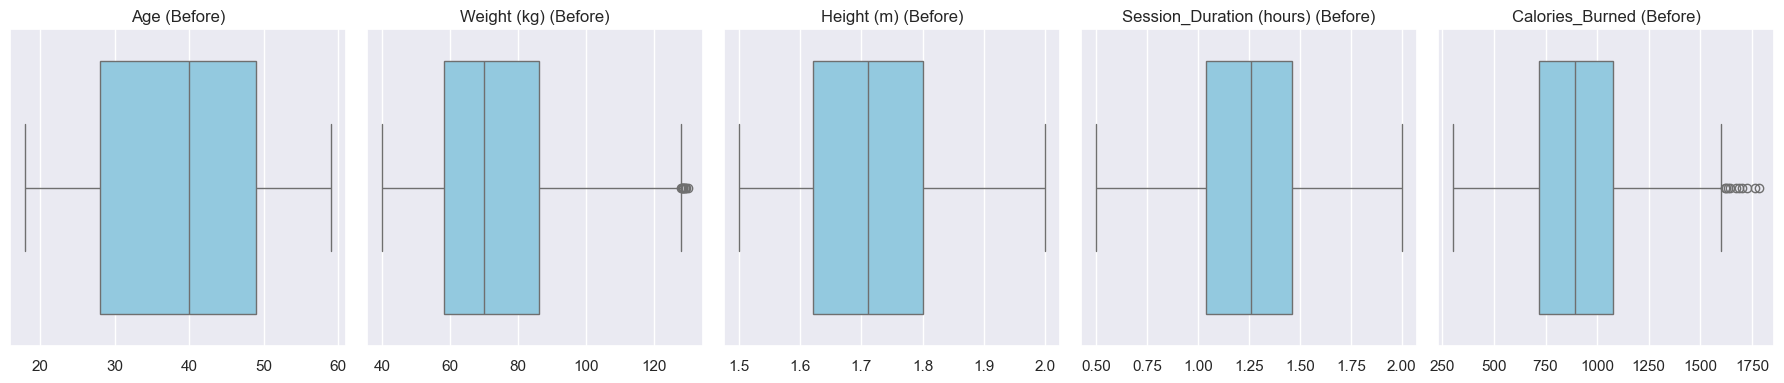

Total rows after removing outliers (Cleaned): 928


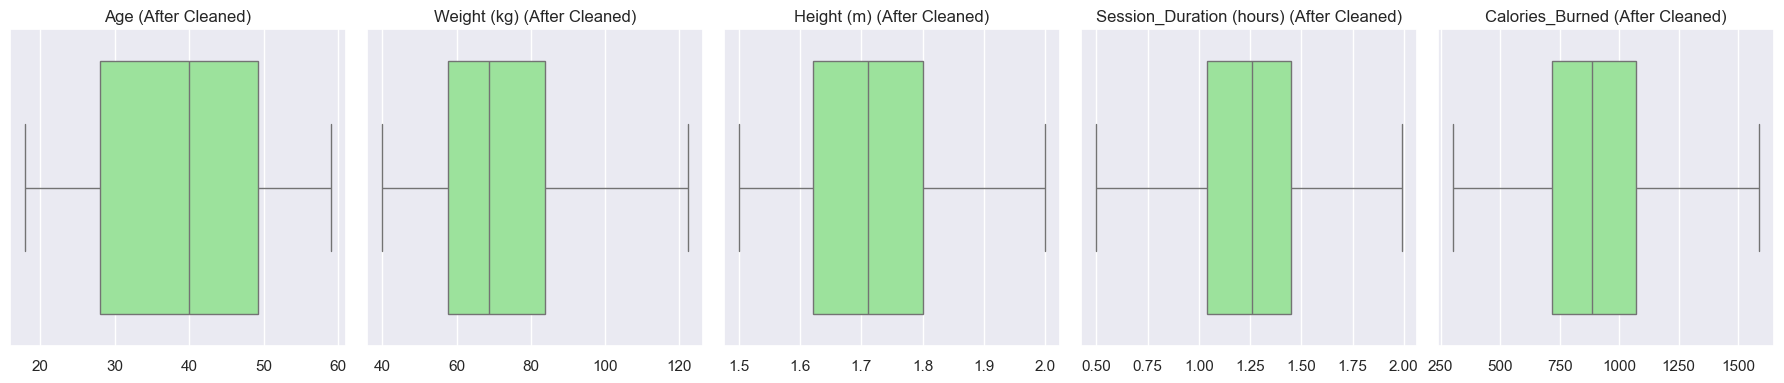

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. List of numerical columns to check for outliers
num_cols = ["Age", "Weight (kg)", "Height (m)", "Session_Duration (hours)", "Calories_Burned"]

print(f"Total rows before removing outliers: {df.shape[0]}")

# 2. Visualize Box Plots BEFORE removing outliers
plt.figure(figsize=(18, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"{col} (Before)")
    plt.xlabel("")
plt.tight_layout()
plt.show()

# 3. Run the IQR filter SEVEN TIMES (7 Iterations) to clean remaining outliers
for iteration in range(7):
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Total rows after removing outliers (Cleaned): {df.shape[0]}")

# 4. Visualize Box Plots AFTER removing outliers again
plt.figure(figsize=(18, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"{col} (After Cleaned)")
    plt.xlabel("")
plt.tight_layout()
plt.show()

### **10. Label Encode Catogorical Data**

In [13]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type
0,56,1,88.3,1.71,1.69,1313.0,Yoga
1,46,0,74.9,1.53,1.30,883.0,HIIT
2,32,0,68.1,1.66,1.11,677.0,Cardio
3,25,1,53.2,1.70,0.59,532.0,Strength
4,38,1,46.1,1.79,0.64,556.0,Strength



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type
967,20,1,55.0,1.60,1.12,1035.0,Yoga
968,24,1,87.1,1.74,1.57,1364.0,Strength
969,25,1,66.6,1.61,1.38,1260.0,Strength
970,59,0,60.4,1.76,1.72,929.0,Cardio
972,46,1,88.7,1.63,0.75,542.0,Strength


### **11. One-Hot Encoding Encode Catogorical Data**

In [14]:
df = pd.get_dummies(df, columns=["Workout_Type"], drop_first=True, dtype=int)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,56,1,88.3,1.71,1.69,1313.0,0,0,1
1,46,0,74.9,1.53,1.30,883.0,1,0,0
2,32,0,68.1,1.66,1.11,677.0,0,0,0
3,25,1,53.2,1.70,0.59,532.0,0,1,0
4,38,1,46.1,1.79,0.64,556.0,0,1,0



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
967,20,1,55.0,1.60,1.12,1035.0,0,0,1
968,24,1,87.1,1.74,1.57,1364.0,0,1,0
969,25,1,66.6,1.61,1.38,1260.0,0,1,0
970,59,0,60.4,1.76,1.72,929.0,0,0,0
972,46,1,88.7,1.63,0.75,542.0,0,1,0


### **12. Normalize features using MinMaxScaler**

In [15]:
scaler = MinMaxScaler()

scale_cols = ["Age", "Weight (kg)", "Height (m)", "Session_Duration (hours)", "Calories_Burned"]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,0.926829,1,0.586877,0.42,0.798658,0.786604,0,0,1
1,0.682927,0,0.424058,0.06,0.536913,0.451713,1,0,0
2,0.341463,0,0.341434,0.32,0.409396,0.291277,0,0,0
3,0.170732,1,0.160389,0.40,0.060403,0.178349,0,1,0
4,0.487805,1,0.074119,0.58,0.093960,0.197040,0,1,0



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
967,0.048780,1,0.182260,0.20,0.416107,0.570093,0,0,1
968,0.146341,1,0.572296,0.48,0.718121,0.826324,0,1,0
969,0.170732,1,0.323208,0.22,0.590604,0.745327,0,1,0
970,1.000000,0,0.247874,0.52,0.818792,0.487539,0,0,0
972,0.682927,1,0.591738,0.26,0.167785,0.186137,0,1,0


## **Tarin Model**

### **13. Split the dataset into Features (X) and Target (y)**

In [16]:
# Inputs (Features)
X = df[['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Session_Duration (hours)', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga']]

# Output (Target)
y = df['Calories_Burned']

### **14. Split the data into Training and Testing sets (Train-Test Split).**

In [17]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 742, Testing samples: 186


### **15. Train and evaluate the Linear Regression model.**
### ***Linear Regression***

##### **Mean Squared Error (MSE)**
* *Low value* → Good model, predictions are close to actual values.
* *High value* → Poor model, predictions are far from actual values.

##### **Root Mean Squared Error (RMSE)**
* *Low value* → Good model, small prediction errors.
* *High value* → Poor model, large prediction errors.

##### **R² Score (Accuracy)**
* *Close to 1.00* → Excellent model performance.
* *Around 0.50* → Moderate model performance
* *Close to 0.00 or negative* → Poor model performance.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Create the model.
model = LinearRegression()

# 2. Train (fit) the model using the training data.
model.fit(X_train, y_train)

# 3. Use the test data to make predictions.
y_pred = model.predict(X_test)

# 4. Evaluate the model's performance.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Accuracy): {r2:.2f}") 

Mean Squared Error (MSE): 0.01
Root Mean Squared Error (RMSE): 0.07
R² Score (Accuracy): 0.86


### **16. Model Evaluation and Visualization**

##### **Graph 1: Actual vs. Predicted Calories Plot**

* Shows the actual calories and the calories predicted by the model.
* The red dashed line shows perfect predictions.
* Most points are close to the line, which means the model predicts very accurately.

##### **Graph 2: Distribution of Residuals (Errors) Plot**

* Shows the difference between actual and predicted values.
* The red dashed line represents zero error.
* Most errors are close to zero, which means the model makes only small mistakes and has no major bias.

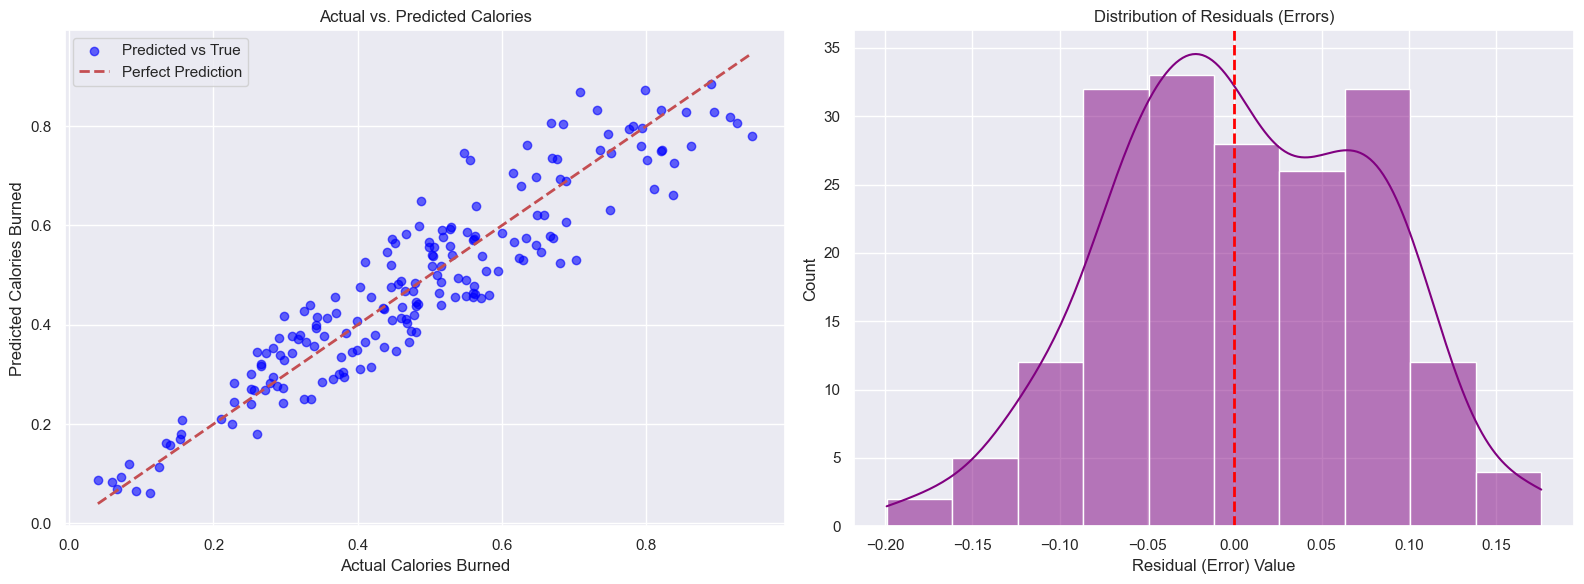

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual vs Predicted Calories 
axes[0].scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs True')

# Perfect Prediction Line
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Calories Burned')
axes[0].set_ylabel('Predicted Calories Burned')
axes[0].set_title('Actual vs. Predicted Calories')
axes[0].legend()
axes[0].grid(True)

# Graph 2: Residuals Distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Error) Value')
axes[1].set_title('Distribution of Residuals (Errors)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### **17. Test the traine model by giving sample value.**

In [20]:
# 1. Define Sample User Data
sample_input_raw = pd.DataFrame([{
    'Age': 46,
    'Gender': 0,                     # Male = 1, Female = 0
    'Weight (kg)': 74.9,
    'Height (m)': 1.53,
    'Session_Duration (hours)': 1.30, 
    'Workout_Type_HIIT': 1,          
    'Workout_Type_Strength': 0,      
    'Workout_Type_Yoga': 0
}])

# 2. Add a temporary value (0) for 'Calories_Burned' to match the scaler's expected format

# Create a copy of the input data
sample_for_scaling = sample_input_raw.copy()
sample_for_scaling['Calories_Burned'] = 0       # Temporary dummy value

# Arrange columns in the same order used when fitting the scaler
sample_for_scaling = sample_for_scaling[scale_cols]

# Scale the data to values between 0 and 1 using MinMaxScaler
sample_scaled_matrix = scaler.transform(sample_for_scaling)

# Store the scaled feature values (excluding Calories_Burned) in a new DataFrame
sample_input_scaled = sample_input_raw.copy()
sample_input_scaled[['Age', 'Weight (kg)', 'Height (m)', 'Session_Duration (hours)']] = sample_scaled_matrix[:, :-1]

# 3. Use the scaled data to make a prediction with the AI model
predicted_calories_scaled = model.predict(sample_input_scaled)[0]

# 4. Convert the predicted value back to the original calorie scale
calories_min = scaler.data_min_[-1]
calories_max = scaler.data_max_[-1]
actual_predicted_calories = predicted_calories_scaled * (calories_max - calories_min) + calories_min

# 5. Display the final result
print("="*50)
print(f"Predicted Calories Burned: {actual_predicted_calories:.2f} kcal")
print("="*50)

Predicted Calories Burned: 862.92 kcal


### **18. Export the Model**

In [21]:
import joblib
import os

# Define the paths where files will be saved
model_path = r"D:/My_Projects/Project_02_GYM_Mobile_App/AI_Models/saved_models/AI_01_Calories_Model.joblib"
scaler_path = r"D:/My_Projects/Project_02_GYM_Mobile_App/AI_Models/saved_models/AI_01_Calories_Scaler.joblib"

# Automatically create the folder if it does not exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save the model and scaler as .joblib files
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

print("✅ Calories Model & Scaler saved successfully as .joblib files!")

✅ Calories Model & Scaler saved successfully as .joblib files!
